# Strategic insights: how SEO/GEO managers should adapt content strategy

**Dissertation:** *Beyond the Visibility Score: Auditing Source Prominence, Citation Accuracy, and Metric Stability Across Five Generative Engines*

**Research question:** *How should SEO/GEO managers adapt content strategy given how generative engines differ in surfacing and citing web sources?*

This notebook consolidates the **thirteen most noteworthy and distinct strategic adaptations** supported by the scale-up study. Each insight follows a fixed structure:

1. **Insight title** — the strategic claim.
2. **Engine mechanics** — how generative engines process this element, contrasted with traditional search, with the study's visibility metrics.
3. **Managerial adaptation** — actionable recommendations for SEO/GEO content pipelines.
4. **Visuals** — the study's own figures (embedded from `figures/scaleup/`) plus, where useful, illustrative charts generated below.

---

### Evidence base

| Element | Specification |
|---|---|
| Design | 250 queries × 5 engines (ChatGPT, Claude, Gemini, Kimi, Perplexity) × k = 8 repeats (9,992 responses; one absent cell) |
| Citations analysed | 58,851 citation events; 47,852 with fetchable page text (81.3%) |
| Prominence metric | **PAWC_norm** (normalised source prominence): position-weighted supported-content mass, normalised to [0, 1] |
| Accuracy metric | **AIS** (Attributable-to-Identified-Sources rate): share of answer sentences clearly supported (NLI entailment ≥ τ = 0.50) by a cited source |
| Stability metric | **CV** (coefficient of variation) of PAWC_norm and AIS across the k = 8 repeats |
| Page-feature models | 21 on-page writing features → early citation (logit), clearly-supported share (OLS), re-citation stickiness (OLS); cluster-robust SEs, BH-FDR |

All effect sizes quoted below are **associations among already-cited pages**, not causal estimates, and page-feature models cannot speak to *whether* a page gets cited in the first place (no uncited counterfactual set).


## Setup

Global visual configuration per the dissertation *Visual Style Guide* (engine palette, typography, axes). Run this cell before any chart cell below.


In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# --- Dissertation Visual Style Guide (mandatory) ---
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.edgecolor"] = "#374151"
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["axes.labelpad"] = 10
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.grid"] = True
mpl.rcParams["axes.grid.axis"] = "y"
mpl.rcParams["grid.color"] = "#E5E7EB"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["axes.axisbelow"] = True
mpl.rcParams["xtick.direction"] = "out"
mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["figure.figsize"] = (7, 4.5)
mpl.rcParams["figure.dpi"] = 150          # screen; export at 300 if reused
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"

ENGINE_COLOURS = {
    "chatgpt":    "#2CA058",
    "claude":     "#D97706",
    "gemini":     "#2563EB",
    "kimi":       "#7C3AED",
    "perplexity": "#0891B2",
}
ENGINE_ORDER  = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_LABELS = {"chatgpt": "ChatGPT", "claude": "Claude", "gemini": "Gemini",
                 "kimi": "Kimi", "perplexity": "Perplexity"}
ENGINE_MARKERS = {"chatgpt": "o", "claude": "s", "gemini": "^",
                  "kimi": "D", "perplexity": "X"}
COLOUR_PRIMARY, COLOUR_NEUTRAL = "#1F4E79", "#6B7280"
COLOUR_REFERENCE, COLOUR_GRID  = "#DC2626", "#E5E7EB"
NEG_POLE = "#B45309"   # divergent negative pole (signed quantities)

def apply_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#374151")
    ax.spines["bottom"].set_color("#374151")
    ax.yaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4, labelsize=11)

import os
FIGDIR = "figures/scaleup/insights"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")
    print("saved", name)


---
## Insight 1 — Allocate GEO effort as a portfolio across engines, weighted by realised citation opportunity, not user market share

### Engine mechanics
Traditional SEO optimises against one dominant index: a page that ranks on Google is, with high probability, *retrievable* for every searcher. Generative engines break this assumption twice. First, each engine decides **per query, per run** whether to retrieve web sources at all; second, when it does retrieve, engines differ sharply in how much prominence any source can earn. In the scale-up study:

- **Unconditional source prominence** (PAWC_norm, counting no-source runs as zero) spans a **~5× gap**: Perplexity ≈ 0.46 vs ChatGPT ≈ 0.09. ChatGPT returned **zero source prominence on 173 of 250 queries**; Kimi and Perplexity on only 3 each.
- **Conditional on retrieving**, ChatGPT jumps to ≈ 0.44 — near the top of the league. Its problem is the retrieval gate, not what it does with sources. Gemini shows the opposite pathology: it searches often but surfaces sources weakly (conditional ≈ 0.30).
- **Citation accuracy** (AIS) spans a wider gap still: Perplexity 0.79 and Kimi 0.78 versus Gemini 0.51 and ChatGPT 0.12.

An engine can therefore be a large *audience* but a small *citation opportunity*. ChatGPT's enormous user base yields almost no attributable visibility for evergreen content; Perplexity's smaller base yields the most frequent, most prominent, and most faithful citations in the study.

### Managerial adaptation
- Budget GEO content effort by **expected attributable visibility** = P(engine retrieves for your query class) × conditional prominence × accuracy — not by engine market share.
- In this study's data that ranking is: **Perplexity and Kimi first** (near-universal retrieval, high AIS), **Claude second** (moderate retrieval, strong conditional metrics), **Gemini third** (retrieves but surfaces weakly and mis-cites), **ChatGPT last for evergreen content** — but see Insight 2 for the freshness exception that reopens it.
- Track each engine as a separate distribution channel with its own KPI baseline; a single blended "AI visibility score" hides the 5× spread.

### Visuals — study figures
![Unconditional PAWC_norm by engine](figures/scaleup/rq/fig_rq1_q1_pawcnorm_unconditional.png)
*Unconditional mean PAWC_norm per engine (no-retrieval runs counted as zero) — the realised size of each engine's citation opportunity.*

![Unconditional vs conditional PAWC_norm](figures/scaleup/rq/fig_rq1_q2_uncond_vs_cond.png)
*Unconditional vs conditional-on-searching prominence separates "rarely retrieves" (ChatGPT) from "retrieves but surfaces weakly" (Gemini).*


### Visuals — generated chart: the opportunity map
Conditional prominence and accuracy per engine, from the study's baseline table (PAWC_norm means over runs with retrieved sources; AIS means over all runs).


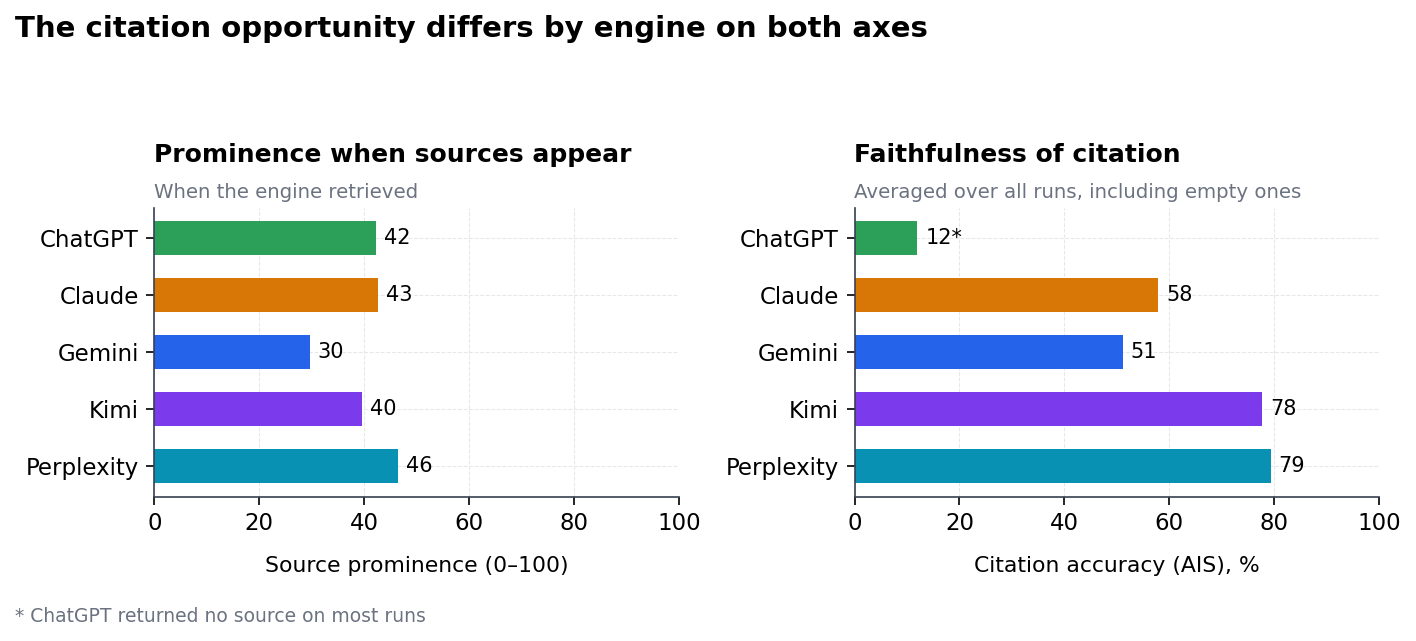

In [2]:
# Verified baseline values (EDA scale-up, cleaned metrics)
pawc_cond = {"chatgpt": 0.422, "claude": 0.426, "gemini": 0.296,
             "kimi": 0.396, "perplexity": 0.464}   # non-null runs only
ais_mean  = {"chatgpt": 0.120, "claude": 0.579, "gemini": 0.511,
             "kimi": 0.777, "perplexity": 0.793}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
# Display transform only: prominence and accuracy shown on a 0-100 scale
# (stored dicts are unchanged 0-1 values).
panels = [
    (axes[0], pawc_cond, "Source prominence (0–100)", False),
    (axes[1], ais_mean,  "Citation accuracy (AIS), %",      True),
]
for ax, vals, label, is_right in panels:
    engines = ENGINE_ORDER
    y = np.arange(len(engines))[::-1]
    ax.barh(y, [vals[e] * 100 for e in engines], height=0.6,
            color=[ENGINE_COLOURS[e] for e in engines])
    for yi, e in zip(y, engines):
        star = "*" if (is_right and e == "chatgpt") else ""
        ax.text(vals[e] * 100 + 1.5, yi, f"{vals[e] * 100:.0f}{star}",
                va="center", fontsize=10)
    ax.set_yticks(y, [ENGINE_LABELS[e] for e in engines])
    ax.set_xlim(0, 100)
    ax.set_xlabel(label, fontsize=10.5)
    ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
    ax.yaxis.grid(False)
    apply_style(ax)
axes[0].set_title("Prominence when sources appear", fontsize=12, loc="left", pad=22)
axes[1].set_title("Faithfulness of citation", fontsize=12, loc="left", pad=22)
axes[0].text(0, 1.02, "When the engine retrieved", transform=axes[0].transAxes,
             ha="left", va="bottom", fontsize=9.5, color="#6B7280")
axes[1].text(0, 1.02, "Averaged over all runs, including empty ones",
             transform=axes[1].transAxes, ha="left", va="bottom",
             fontsize=9.5, color="#6B7280")
fig.suptitle("The citation opportunity differs by engine on both axes", x=0.01,
             ha="left", fontsize=14, fontweight="bold")
fig.text(0.01, 0.01, "* ChatGPT returned no source on most runs",
         ha="left", va="bottom", fontsize=9, color="#6B7280")
fig.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()


---
## Insight 2 — Treat the retrieval decision, not the ranking, as the first conversion gate; freshness signals open it

### Engine mechanics
In traditional search the index is always consulted — every query produces a ranked list, so optimisation begins at position. Generative engines insert a **prior gate**: a per-run model decision on whether to search the web at all. If the gate stays closed, PAWC_norm and AIS are zero regardless of content quality — no amount of on-page optimisation is visible.

The gate is strongly **temporality-driven and engine-specific**:

- ChatGPT searched on only **11.7% of evergreen-query runs but 81.4% of "latest"-query runs** — a 7× swing, and the primary cause of its 75.8% zero-citation run rate.
- Claude (72% → 89%) and Gemini (62% → 92%) show the same direction, softer.
- Kimi (~97%) and Perplexity (100%) search essentially always — retrieval-first architectures with no meaningful gate.
- Consistently, the page-feature models find that on Kimi, pages mentioning a **recent year (2024+) gain +0.30 log-odds of an early citation slot** — one of only two significant early-position levers in 90 tested feature–engine cells.

### Managerial adaptation
- For gated engines (ChatGPT above all), **content that carries explicit recency cues** — dated statistics, "as of [year]" statements, updated timestamps, coverage of current developments — is not just a ranking factor; it changes whether retrieval happens at all.
- Maintain an **update cadence** on cornerstone pages: refreshing an evergreen page with current-year data points converts it from a query class the gate ignores into one it opens for.
- Segment your query portfolio by temporality when forecasting GEO traffic: evergreen informational queries will structurally under-deliver on gated engines, whatever you publish.

### Visuals — study figures
![Zero-citation rate by engine](figures/scaleup/fig_eda_rc1_zero_citation_rate.png)
*ChatGPT produced no citations in 75.8% of its 2,000 runs; Perplexity in 0%.*

![Search rate by temporality](figures/scaleup/fig_eda_16_search_rate_by_temporality.png)
*The retrieval gate is temporality-driven, and the swing is engine-specific.*


### Visuals — generated chart: the retrieval gate, evergreen vs latest


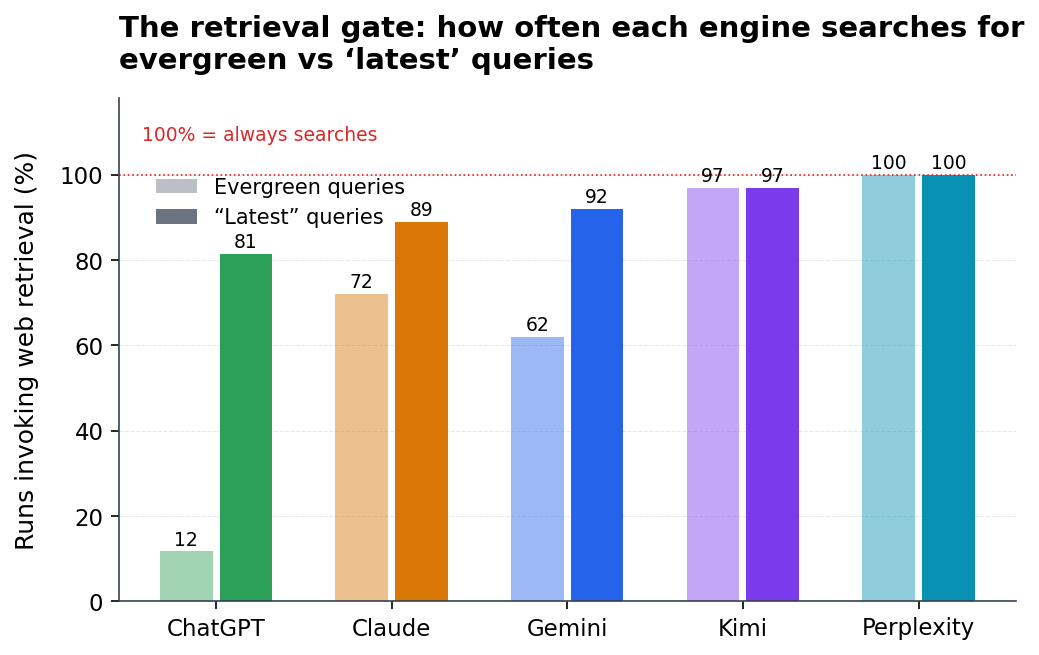

In [3]:
# Verified search rates (% of runs invoking web retrieval), by query temporality
search_evergreen = {"chatgpt": 11.7, "claude": 72.0, "gemini": 62.0,
                    "kimi": 97.0, "perplexity": 100.0}
search_latest    = {"chatgpt": 81.4, "claude": 89.0, "gemini": 92.0,
                    "kimi": 97.0, "perplexity": 100.0}

x = np.arange(len(ENGINE_ORDER))
w = 0.3
fig, ax = plt.subplots(figsize=(7, 4.5))
for off, vals, alpha, lab in [(-w/2 - 0.02, search_evergreen, 0.45, "Evergreen queries"),
                              (+w/2 + 0.02, search_latest,    1.00, "“Latest” queries")]:
    ax.bar(x + off, [vals[e] for e in ENGINE_ORDER], width=w,
           color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER], alpha=alpha,
           label=lab)
    for xi, e in zip(x + off, ENGINE_ORDER):
        ax.text(xi, vals[e] + 1.5, f"{vals[e]:.0f}", ha="center", fontsize=9)
ax.set_xticks(x, [ENGINE_LABELS[e] for e in ENGINE_ORDER])
ax.set_ylabel("Runs invoking web retrieval (%)")
ax.set_ylim(0, 118)
ax.set_title("The retrieval gate: how often each engine searches for\nevergreen vs ‘latest’ queries", loc="left", pad=14)
ax.axhline(100, color=COLOUR_REFERENCE, linewidth=0.8, linestyle=":")
ax.text(-0.42, 108, "100% = always searches", color=COLOUR_REFERENCE, fontsize=9, ha="left")
# alpha encodes temporality (legend inside, upper-left free area); colour encodes engine
handles = [plt.Rectangle((0, 0), 1, 1, fc=COLOUR_NEUTRAL, alpha=a) for a in (0.45, 1.0)]
ax.legend(handles, ["Evergreen queries", "“Latest” queries"],
          loc="upper left", bbox_to_anchor=(0.02, 0.88), fontsize=10)
apply_style(ax)
fig.tight_layout()
plt.show()


---
## Insight 3 — Abandon the single-leaderboard mindset: visibility wins do not transfer across engines

### Engine mechanics
Traditional SEO has one leaderboard — Google's ranking — so one optimisation effort covers ~90% of the search market. Generative engines behave as **five weakly-correlated retrieval systems**. Across the 250-query panel:

- The **strongest cross-engine agreement** on per-query prominence is Claude–Gemini at ρ = 0.59; every other pair is weaker.
- **Perplexity agrees with no one** (ρ ≈ 0.11–0.25 with every other engine) despite being the largest opportunity — its retrieval is the most idiosyncratic.
- Agreement does not improve inside topic verticals: the best within-topic cross-engine correlation is only ρ ≈ 0.27 (health, politics); arts and history sit near ρ ≈ 0.03.
- Even the *source diet* differs structurally: government pages carry 19% of ChatGPT's prominence mass, editorial blogs power Claude (15%) and Kimi (18%), while Wikipedia — 8% of Perplexity's mass — is almost absent from Kimi (0.1%).

Being the most-cited source on one engine is therefore close to **uninformative** about your standing on another.

### Managerial adaptation
- Replace the single "AI visibility rank" with a **per-engine visibility scorecard**; set targets and diagnose failures engine by engine.
- Prioritise **two or three engines** aligned with your audience and content type (Insight 1's portfolio logic) rather than spreading effort thinly across all five.
- Where an engine has a distinct source-type currency (Insight 8), commission content *variants* — an institutional/reference-style asset for Perplexity, editorial explainers for Claude/Kimi — instead of assuming one asset serves all engines.

### Visuals — study figures
![Cross-engine agreement correlations](figures/scaleup/rq/fig_rq2_q9_engine_agreement_corr.png)
*Pairwise Spearman correlations of per-query prominence: the strongest pair reaches only ρ = 0.59.*

![Engine agreement by topic](figures/scaleup/domain/fig_domain_rq2_d6_engine_agreement_by_topic.png)
*No topic vertical exceeds ρ ≈ 0.27 — there is no niche where optimising for one engine carries the others.*


---
## Insight 4 — Faithful citation *is* writable, and one writing playbook serves all five engines

### Engine mechanics
Generative engines do something traditional search never did: they **paraphrase your content and attach your name to the paraphrase**. The NLI audit shows this step is where pages win or lose — and, unlike visibility, it responds to on-page writing. Of 90 feature–engine cells tested, **36 significantly predict being clearly supported** (vs 5 for citation position). The strongest replicated levers:

- **Lead query coverage** — opening lines that reuse the query's own words: **+4 to +11 percentage points** of clearly-supported share per SD, significant on *every* engine (ChatGPT +10.8, Kimi +6.1) (5/5 engines).
- **Question-style titles**: +3 to +7 pp on four of five engines (4/5).
- **Denser, information-carrying wording**: +6 to +11 pp (all but ChatGPT; 4/5).
- Negative levers: **entity name-dropping** (−4 to −5 pp on Kimi, Perplexity) (2/5), **sprawling multi-topic pages** (−3 to −5 pp on Claude, Kimi) (2/5), and long titles consistently hurt.

Critically, the sign pattern of these traits is **consistent across engines** — the one place in the study where optimisation transfers. Answer-engine summarisers appear to verify claims similarly even though their retrievers rank differently.

### Managerial adaptation
- Institutionalise a single **"citable writing" standard** in the content pipeline: answer the target query *verbatim in the first lines*, in the title where natural, in declarative self-contained sentences.
- Add an editorial checklist item: every claim you want cited must be **checkable against the page text as written** — an NLI model (and an engine's grounding check) must find the supporting sentence.
- De-prioritise entity-stuffing and topic-sprawl tactics inherited from classic SEO; in this data they *reduce* faithful citation.

### Visuals — study figures
![Support-model forest plot](figures/scaleup/pagefeat/fig_pf_q2_support_forest.png)
*Per-engine coefficients: which writing features predict clearly-supported citation.*

![Cross-engine sign consistency](figures/scaleup/pagefeat/fig_pf_q4_support_z_heatmap.png)
*Faithfulness levers point the same way on essentially every engine — one playbook transfers.*


### Visuals — generated chart: the writable levers
Representative mid-points of the cross-engine effect ranges above (illustrative summary of the forest plot; per-engine values and CIs are in `fig_pf_q2_support_forest`).


saved fig_insights_i04_writable_levers


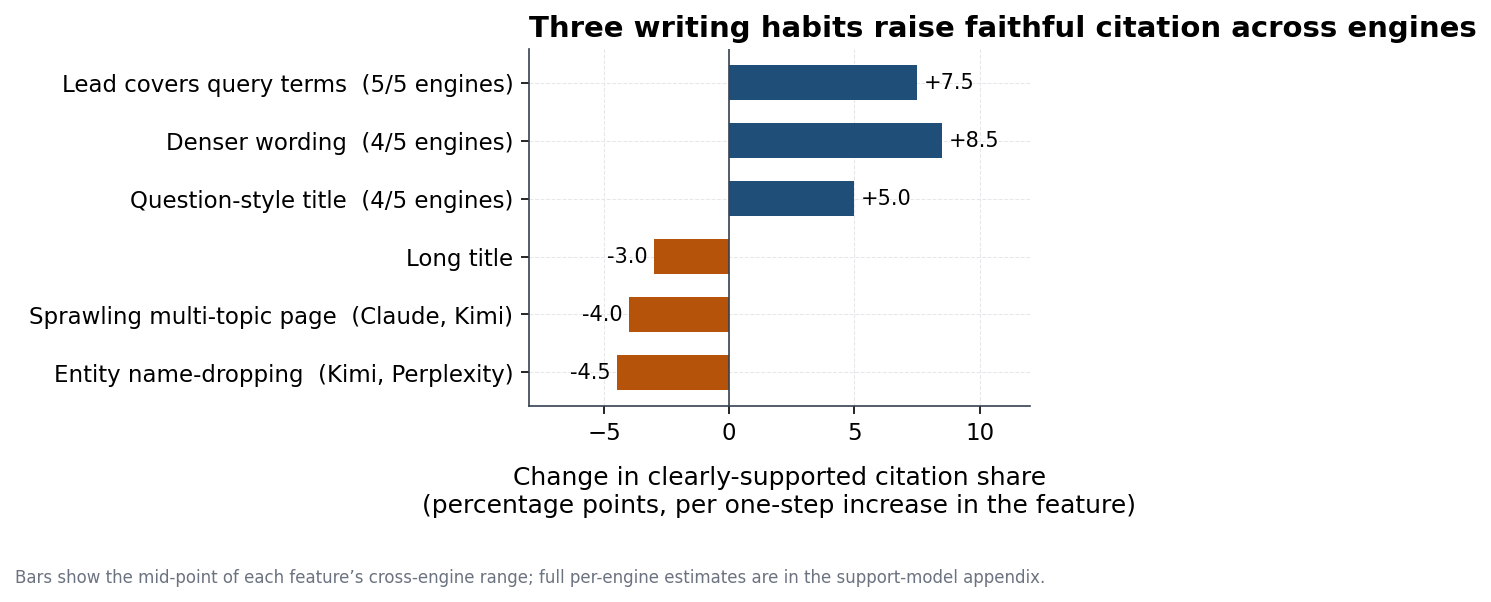

In [4]:
levers = [
    ("Lead covers query terms",    +7.5, "5/5 engines"),      # +4 to +11 pp per SD, all engines
    ("Denser wording",             +8.5, "4/5 engines"),      # +6 to +11 pp, 4/5 engines
    ("Question-style title",       +5.0, "4/5 engines"),      # +3 to +7 pp, 4/5 engines
    ("Long title",                 -3.0, None),
    ("Very long page", -4.0, "Claude, Kimi"),     # -3 to -5 pp (Claude, Kimi)
    ("Entity name-dropping",       -4.5, "Kimi, Perplexity"), # -4 to -5 pp (Kimi, Perplexity)
]
labels = [(f"{l}  ({r})" if r else l) for l, _, r in levers][::-1]
vals   = np.array([v for _, v, _ in levers])[::-1]

fig, ax = plt.subplots(figsize=(7, 4.0))
ax.barh(np.arange(len(vals)), vals, height=0.6,
        color=[COLOUR_PRIMARY if v > 0 else NEG_POLE for v in vals])
ax.axvline(0, color="#374151", linewidth=0.8)
for i, v in enumerate(vals):
    ax.text(v + (0.25 if v > 0 else -0.25), i, f"{v:+.1f}",
            va="center", ha="left" if v > 0 else "right", fontsize=10)
ax.set_yticks(np.arange(len(vals)), labels)
ax.set_xlabel("Change in clearly-supported citation share\n(percentage points, per one-step increase in the feature)")
ax.set_title("Three writing habits raise faithful citation across engines", loc="left")
ax.set_xlim(-8, 12)
ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
ax.yaxis.grid(False)
apply_style(ax)
fig.text(0.01, 0.005,
         "Bars show the mid-point of each feature’s cross-engine range; full per-engine estimates are in the support-model appendix.",
         ha="left", va="bottom", fontsize=8, color="#6B7280")
fig.tight_layout(rect=[0, 0.08, 1, 1])
savefig(fig, "fig_insights_i04_writable_levers")
plt.show()


---
## Insight 5 — Stop trying to write your way up the citation list: early position is earned at site level

### Engine mechanics
Position in a generative answer's citation list is the closest analogue to a traditional SERP rank — and position matters, because PAWC weights early citations more heavily. But the page-feature models show early position is **essentially not writable**: only **5 of 90 feature–engine cells** survive FDR correction for the first-3-slot outcome. Instead, position tracks **source identity**:

- **Wikipedia is cited at median position 3**, reference and food-content sites at 4, most source types at 5, databases at 6 — a stable hierarchy of institutional trust.
- The two writable exceptions are narrow: on Perplexity, **title–query word overlap** raises early-slot odds (+0.28 log-odds per SD — the most lexical retriever in the study), and on Kimi, **2024+ freshness signals** (+0.30 log-odds; see Insight 2).

This mirrors, in harsher form, the classic SEO lesson that domain authority dominates on-page tweaks — except here there is no long tail of positions to win: most answers cite a handful of sources, and everything below the fold of the citation list effectively vanishes from PAWC mass.

### Managerial adaptation
- Reallocate effort from **on-page position hacks to site-level authority building**: digital PR, institutional partnerships, presence in the reference layer (Wikipedia, recognised databases and directories) that engines slot early by default.
- Where you cannot be the early-cited source, be the source the early one relies on — being cited *by* encyclopedic and reference intermediaries propagates into engine answers.
- Keep the two writable exceptions in the playbook: exact query phrasing in titles (Perplexity) and visible freshness (Kimi/ChatGPT gate).

### Visuals — study figures
![Early-citation forest plot](figures/scaleup/pagefeat/fig_pf_q1_early3_forest.png)
*Almost nothing on-page predicts an early citation slot.*

![Citation position by source type](figures/scaleup/domain/fig_domain_rq1_d3_position_by_domain_type.png)
*Position is a property of source identity: Wikipedia at median position 3, databases at 6.*


---
## Insight 6 — Classic keyword relevance survives as the driver of *repeat* citation — optimise for stickiness, not one-off wins

### Engine mechanics
Because engines re-retrieve on every run, a citation is not a durable asset the way a ranking is: the study measures **re-citation stickiness** — whether a page cited once is cited again across the k = 8 repeats. The levers that predict stickiness are strikingly familiar:

- **Title–query word overlap**: +4.5 pp (Kimi) and +5.0 pp (Perplexity) re-citation probability per SD.
- **Lead query coverage**: +5.7 pp (Claude), +3.0 pp (Kimi).
- Claude also rewards **digit-dense pages** (+8.3 pp) and **listicle-style titles** (+14.4 pp for having one) — structured, enumerable content is easiest to re-select and quote.
- Gemini's domain-level model agrees on the query-match traits; ChatGPT shows nothing significant (too few citation events, n = 556 pairs).

This is the closest thing to classic SEO in the generative world: **lexical relevance between the query and your title/lead is what makes engine retrieval reproducibly find you**, run after run.

### Managerial adaptation
- Target **query–title–lead alignment** exactly as you would for a featured snippet: one page per target query formulation, phrased the way users ask it.
- Measure GEO success as **citation share across repeated runs** (stickiness), not single-observation "we got cited" screenshots — one-off citations are substantially retrieval noise (see Insight 10).
- For Claude specifically, structured formats (numbered lists, concrete figures) measurably raise the chance the same page is re-selected.

### Visuals — study figures
![Stickiness forest plot](figures/scaleup/pagefeat/fig_pf_q3_sticky_forest.png)
*Re-citation across repeats is a keyword-relevance game: title–query overlap and lead query coverage dominate.*


---
## Insight 7 — Re-architect content to mid-length, single-topic units: both stubs and mega-pages fail verification

### Engine mechanics
Traditional SEO folklore rewards exhaustive "skyscraper" pages: more coverage, more headings, more chances to rank. Generative engines invert this at the verification step. The clearly-supported share of citations follows an **inverted-U in page length on every engine**:

- **Thin stubs** (~30 words) verify worst (~8% clearly supported) — there is not enough text to entail any claim.
- **Mega-documents** (17,000–24,000 words) also verify poorly (~12%) — the supporting sentence exists but is buried, and the engine's paraphrase drifts from any single passage.
- **Mid-length, single-topic articles verify best**, and sprawling multi-topic pages independently lose 3–5 pp (Claude, Kimi).

A methodological caveat the study makes explicit: the apparent "focused vocabulary" (type–token ratio) effect is **length-confounded (r = −0.84 with log page length)** — low TTR is mostly a mega-page marker, so interpret length, wording density, and vocabulary as one bundle: *mid-length, focused, moderately technical prose*.

### Managerial adaptation
- **Split skyscraper assets** into families of mid-length, single-intent pages (hub-and-spoke), each answering one query formulation completely.
- Set editorial guardrails at both ends: no thin programmatic stubs (they get cited but not supported), no unbounded "ultimate guides" as citation targets.
- When a long page must exist, ensure each citable claim is **locally self-contained** — a sentence an NLI check can verify without reading the surrounding 10,000 words.

### Visuals — study figures
![Support by page-length decile](figures/scaleup/pagefeat/fig_pf_q5_length_deciles.png)
*Clearly-supported share by page-length decile: an inverted-U on every engine.*


---
## Insight 8 — Choose battlegrounds by vertical: prominence and accuracy are topic-dependent, and each engine has topic strongholds

### Engine mechanics
Engines do not surface sources uniformly across subject matter. Across the 14 well-powered query topics:

- **Prominence is ~1.9× higher in factual/technical verticals** — health 0.415, computers & electronics 0.383, science 0.349, finance 0.341 — than in sports 0.220, history 0.235, politics 0.241 (non-overlapping CIs).
- **Accuracy tracks the same gradient**: AIS is highest for health (0.66), science (0.63), computers (0.62) and lowest for politics (0.46), language (0.48), history (0.48). In interpretive verticals engines answer more from parametric memory and paraphrase more loosely.
- **Topic strongholds differ by engine**: Perplexity leads prominence on 8 of 14 topics, but **Claude overtakes on science, computers & electronics, and arts & entertainment; Kimi leads finance, language, and sports**; Kimi also tops AIS in 8 of 14 topics. ChatGPT trails everywhere.
- Sports is the least reproducible vertical (median PAWC_norm CV 0.66 — the only topic above the instability line), and "latest" queries are less reproducible than evergreen ones generally.

### Managerial adaptation
- **Forecast GEO returns per vertical**: content in health, tech, science, and finance earns systematically more attributable visibility per unit of effort than politics, sports, or history content.
- Match the engine portfolio (Insight 1) to your vertical: a fintech content team should weight Kimi more heavily than category-level engine shares suggest; a developer-tools team, Claude.
- In low-AIS verticals (politics, opinion), expect **loose paraphrase** even when cited — invest in the verifiability tactics of Insights 4 and 9, and monitor brand-safety of misattributed claims.

### Visuals — study figures
![Prominence by query topic](figures/scaleup/domain/fig_domain_rq1_d1_pawcnorm_by_query_domain.png)
*Health queries carry ~1.9× the source prominence of sports queries.*

![Engine × topic heatmap](figures/scaleup/domain/fig_domain_rq1_d2_engine_by_domain_heatmap.png)
*Each engine has topic strongholds — set the engine × vertical strategy from this grid.*

![AIS by topic heatmap](figures/scaleup/domain/fig_domain_rq3_d12_ais_by_topic_heatmap.png)
*Citation accuracy follows the same factual-vs-interpretive gradient.*


---
## Insight 9 — Optimise for *verifiability*, not topical association: most citations are borderline, and some formats are cited to be contradicted

### Engine mechanics
A citation in a generative answer is not an endorsement of what the answer says. Sentence-level NLI auditing of 58,851 citation events shows:

- **43% (Perplexity) to 63% (ChatGPT) of all citations fall in the borderline entailment band** (0.30–0.50) — neither clearly supported nor contradicted.
- Faithfulness is a property of **source format**: Wikipedia citations are clearly supported 62% of the time and healthcare sources 51%, while **video citations are supported only 5% (84% contradicted)** and database citations 10% (68% contradicted). Long-form academic and news sources live in the "maybe" zone (preprints 77%, journals 74%, news 71% borderline).
- **Topical alignment between source and query does nothing for accuracy** (ρ ≈ +0.03, ns; within-topic −0.01) — *being on-topic doesn't help; being checkable does.*
- Engine source diets amplify this: **Gemini draws 20% of its citations from low-faithfulness formats** (forum/video/database/research) — ~3× Kimi's 7% — a real driver of its AIS of 0.51.

For a manager, the risk is inverted from classic SEO: your brand can appear as the *cited source of a claim your content never made*.

### Managerial adaptation
- Publish **text-first, claim-explicit versions** of every asset that lives natively in a low-faithfulness format: transcripts and key-findings summaries for videos and webinars; narrative "what this data shows" pages in front of databases and interactive tools.
- Write so that machine verification succeeds: numbers stated in full sentences, claims verbatim-checkable, conclusions not solely in figures or tables (see Insight 4's checklist).
- Add **misattribution monitoring** to brand safety: sample engine answers citing your domain (especially on Gemini and ChatGPT) and NLI-check them against your pages, because prominence does not guarantee faithful use there (ρ(PAWC_norm, AIS) ≈ 0.3–0.4 on those two engines vs 0.6–0.7 on Perplexity/Kimi/Claude).

### Visuals — study figures
![Entailment bands by engine](figures/scaleup/rq/fig_rq3_q13_entail_bands.png)
*Between 43% and 63% of citations are borderline — "maybe", not clean support.*

![Faithfulness by source type](figures/scaleup/domain/fig_domain_rq3_d9_entailment_by_source_type.png)
*Wikipedia 62% clearly supported; video 5% supported and 84% contradicted.*

![Two failure modes](figures/scaleup/domain/fig_domain_rq3_d11_failure_modes.png)
*Borderline paraphrase concentrates in academic/institutional long-form; outright contradiction in UGC and media formats.*


---
## Insight 10 — Build measurement governance into GEO reporting: single-run readings and threshold-blind league tables are untrustworthy

### Engine mechanics
Traditional rank tracking is approximately deterministic — position 3 today is position 3 on re-query. Generative visibility is a **stochastic measurement**, and the study quantifies exactly how unstable:

- ChatGPT has **no measurable prominence on 74% of queries** and a median AIS CV of **1.05** (the score more than doubles or halves between runs); even always-searching Perplexity has **55% of its prominence cells unstable (CV ≥ 0.50)** — a URL/order-level wobble that source-type consistency cannot explain (ρ ≈ +0.01) and only averaging fixes. Claude is the steadiest instrument (median PAWC_norm CV 0.18, AIS CV 0.09).
- At the pilot's k = 3 repeats, up to 10% of cells sat on the mechanical CV ceiling (pure small-k artefact); k = 8 largely clears it. **Roughly eight runs is the minimum viable measurement.**
- League tables depend on the audit's NLI threshold τ: the **AIS engine ranking is invariant across τ = 0.30–0.70**, but the PAWC_norm ranking flips (Kimi 1st at τ = 0.30 → 4th at τ ≥ 0.50; Perplexity the reverse). A prominence ranking quoted without its τ is not interpretable.
- Output formatting can distort scores: on Kimi, ~52% of NLI-"supported" sentences were formatting artifacts before cleaning — third-party GEO trackers that don't segment and clean responses will systematically mis-rank engines.

### Managerial adaptation
- Procurement standard for GEO analytics (in-house or vendor): **k ≥ 8 repeated runs per query–engine cell, CV reported alongside every mean, and the entailment/support threshold disclosed** with any cross-engine comparison.
- Set **per-engine decision thresholds**: on Claude a movement of a few points is signal; on ChatGPT almost nothing short of the retrieval gate opening is.
- Report *distributions* to stakeholders, not point estimates — "cited in 6 of 8 runs at mean prominence 0.4 ± 0.1" is an actionable KPI; "we are #2 on AI search" is not.

### Visuals — study figures
![Median CV per engine](figures/scaleup/rq/fig_rq2_q6_median_cv_dotplot.png)
*Run-to-run stability differs by an order of magnitude across engines.*

![CV ceiling at k=8 vs k=3](figures/scaleup/rq/fig_rq2_q11_cv_ceiling_k8_vs_k3.png)
*k = 3 is too few; ~8 repeats is the minimum viable measurement.*

![Rank sensitivity to τ](figures/scaleup/rq/fig_rq2_q10_rank_by_tau_bump.png)
*The AIS ranking never moves across the τ sweep; the PAWC_norm ranking flips — always disclose τ.*


---
## Insight 11 — Read each engine's citation economy before entering it: Kimi is an open long-tail market, Gemini a platform-gated oligopoly

### Engine mechanics
Traditional SEO taught managers to expect a power law: a handful of authority domains absorb most of page-one real estate, and displacing an incumbent is the whole game. At source level, the five engines run **structurally different citation economies** (58,851 citations mapped to registrable domains):

- **Breadth of the cited universe varies ~11×**: Kimi spread its 18,873 citations across **4,039 domains** and Gemini its 14,263 across 3,673, while ChatGPT's rare retrievals touched only **363 domains** (Claude 1,673; Perplexity 1,643).
- **Concentration varies just as sharply.** The top-10 domains absorb **26.3% of Gemini's** and 23.7% of Perplexity's citation events, but only **8.0% of Kimi's** (Gini 0.64 vs 0.53). Kimi's single most-cited domain (nih.gov) holds just 1.5% of its citations — no incumbent controls meaningful share.
- **Gemini's and Perplexity's head is not publishers but platforms**: YouTube alone is Perplexity's #1 cited domain (10.5%) and Gemini's #1 (7.5%, plus Reddit 6.2% and Quora 1.5%). **UGC/social platforms carry 18.2% of Gemini's and 11.8% of Perplexity's citation mass, versus 1.4–3.5% on ChatGPT, Kimi and Claude.**
- The tail is churn-heavy where it is widest: **53.9% of the domains Gemini ever cited appeared exactly once** in 2,000 runs (13.9% of its citation mass), against 20.6% of Perplexity's (2.4% of mass) — wide tails are entered easily and exited just as easily.

### Managerial adaptation
- **Match market-entry strategy to the economy.** On Kimi, a mid-authority specialist site competes on near-equal footing — the flattest, most contestable citation market in the study and the natural first target for challenger brands. On Gemini and Perplexity, plan for a winner-take-most head you are unlikely to displace directly.
- **Treat platform presence as a GEO surface, not just social marketing.** On Gemini roughly one citation in five goes to YouTube/Reddit/Quora-style platforms: a maintained YouTube explainer or an authoritative Reddit/Quora answer can earn citations your own domain will not. (Pair with Insight 9: video citations verify poorly, so publish the claim-explicit text alongside.)
- **Discount one-off tail citations when reporting share-of-voice**: on Gemini half the "domains cited" are single-appearance noise; count only domains with repeated citations as competitors or as evidence of your own traction.

### Visuals — generated chart: how concentrated is each engine's citation economy?


saved fig_insights_i11_citation_concentration


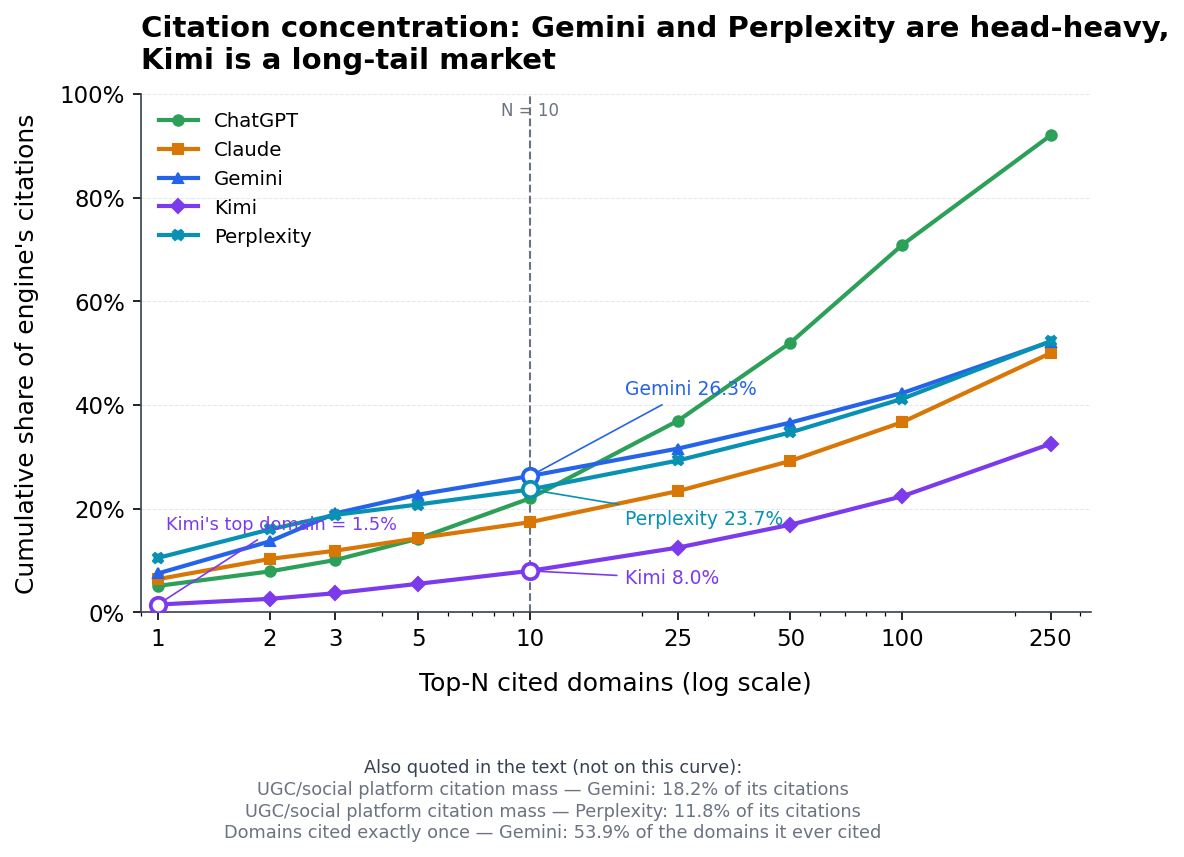

Validation · N=10 and N=1 markers (must equal the text-quoted values exactly):
  Gemini N=10: 26.3% (quoted 26.3%)  |  Perplexity N=10: 23.7% (quoted 23.7%)  |  Kimi N=10: 8.0% (quoted 8.0%)
  Kimi N=1: 1.5% (quoted 1.5%)


In [5]:
# Verified from silver citations_scaleup.parquet (58,851 citations), domains normalised
# to registrable domain (tldextract) before ranking. Cumulative share of each engine's
# citation events captured by its top-N cited domains; curves end at the engine's
# total number of cited domains (ChatGPT: 363).
ranks = [1, 2, 3, 5, 10, 25, 50, 100, 250]
cum_share = {  # cumulative share of engine's citations at top-N domains
    "chatgpt":    [.051, .079, .101, .142, .220, .370, .520, .709, .920],
    "claude":     [.064, .103, .119, .143, .174, .234, .292, .367, .500],
    "gemini":     [.075, .137, .191, .227, .263, .316, .366, .423, .522],
    "kimi":       [.015, .026, .037, .055, .080, .125, .169, .224, .325],
    "perplexity": [.105, .160, .188, .208, .237, .293, .347, .412, .523],
}
# Domains cited per engine (for the figure caption, not the legend):
# ChatGPT 363, Claude 1,673, Gemini 3,673, Kimi 4,039, Perplexity 1,643.
n_domains = {"chatgpt": 363, "claude": 1673, "gemini": 3673,
             "kimi": 4039, "perplexity": 1643}

fig, ax = plt.subplots(figsize=(7.5, 5.8))
for e in ENGINE_ORDER:
    ax.plot(ranks, cum_share[e], color=ENGINE_COLOURS[e], linewidth=2,
            marker=ENGINE_MARKERS[e], markersize=5,
            label=ENGINE_LABELS[e])
ax.set_xscale("log")
ax.set_xticks(ranks, [str(r) for r in ranks])
ax.set_xlim(0.9, 320)
ax.set_ylim(0, 1.0)
ax.set_xlabel("Top-N cited domains (log scale)")
ax.set_ylabel("Cumulative share of engine's citations")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))

# --- N=10 reference: open-circle markers + labels for all three text-quoted engines. Gemini and
#     Perplexity sit close together (26.3% vs 23.7%) -> offset labels vertically with leader lines. ---
r10, r1 = ranks.index(10), ranks.index(1)
ax.axvline(10, color="#6B7280", linewidth=1.0, linestyle="--", zorder=1)
for e in ("gemini", "perplexity", "kimi"):
    ax.scatter([10], [cum_share[e][r10]], s=55, facecolor="white",
               edgecolor=ENGINE_COLOURS[e], linewidth=1.8, zorder=6)
g10, p10, k10 = cum_share["gemini"][r10], cum_share["perplexity"][r10], cum_share["kimi"][r10]
ax.annotate(f"Gemini {g10:.1%}", xy=(10, g10), xytext=(18, 0.42), fontsize=9, color=ENGINE_COLOURS["gemini"],
            arrowprops=dict(arrowstyle="-", color=ENGINE_COLOURS["gemini"], linewidth=0.8))
ax.annotate(f"Perplexity {p10:.1%}", xy=(10, p10), xytext=(18, 0.17), fontsize=9, color=ENGINE_COLOURS["perplexity"],
            arrowprops=dict(arrowstyle="-", color=ENGINE_COLOURS["perplexity"], linewidth=0.8))
ax.annotate(f"Kimi {k10:.1%}", xy=(10, k10), xytext=(18, 0.055), fontsize=9, color=ENGINE_COLOURS["kimi"],
            arrowprops=dict(arrowstyle="-", color=ENGINE_COLOURS["kimi"], linewidth=0.8))
ax.text(10, 0.985, "N = 10", ha="center", va="top", fontsize=8, color="#6B7280")

# --- N=1 reference: Kimi's single most-cited domain ---
k1 = cum_share["kimi"][r1]
ax.scatter([1], [k1], s=55, facecolor="white", edgecolor=ENGINE_COLOURS["kimi"], linewidth=1.8, zorder=6)
ax.annotate(f"Kimi's top domain = {k1:.1%}", xy=(1, k1), xytext=(1.05, 0.16), fontsize=8.5,
            color=ENGINE_COLOURS["kimi"],
            arrowprops=dict(arrowstyle="-", color=ENGINE_COLOURS["kimi"], linewidth=0.8))

ax.set_title("Citation concentration: Gemini and Perplexity are head-heavy,\nKimi is a long-tail market", loc="left", pad=12)
apply_style(ax)
ax.legend(loc="upper left", fontsize=9.5)

# --- Companion table: quoted values not on this curve (plain text, no gridlines, one line each) ---
table_rows = [
    "UGC/social platform citation mass — Gemini: 18.2% of its citations",
    "UGC/social platform citation mass — Perplexity: 11.8% of its citations",
    "Domains cited exactly once — Gemini: 53.9% of the domains it ever cited",
]
fig.text(0.5, 0.10, "Also quoted in the text (not on this curve):", ha="center", fontsize=8.5,
         color="#374151", fontweight="medium")
for i, row in enumerate(table_rows):
    fig.text(0.5, 0.075 - 0.025*i, row, ha="center", fontsize=8.5, color="#6B7280")

fig.tight_layout(rect=[0, 0.16, 1, 1])
savefig(fig, "fig_insights_i11_citation_concentration")
plt.show()

print("Validation · N=10 and N=1 markers (must equal the text-quoted values exactly):")
print(f"  Gemini N=10: {g10:.1%} (quoted 26.3%)  |  Perplexity N=10: {p10:.1%} (quoted 23.7%)  |  Kimi N=10: {k10:.1%} (quoted 8.0%)")
print(f"  Kimi N=1: {k1:.1%} (quoted 1.5%)")


---
## Insight 12 — Decide early which game you are playing: the small cross-engine consensus core, or an engine-private tail

### Engine mechanics
Do the five engines at least draw on the same *supply* of sources? Mostly not. Mapping all 58,851 citations to 8,581 registrable domains:

- **A tiny consensus core exists and punches far above its weight**: only **47 domains (0.5%) were cited by all five engines, yet they absorb 14.7% of every citation in the study**; the 243 domains reached by four or more engines (2.8%) absorb 27.7%. The core's roster is the institutional reference layer — Wikipedia, nih.gov, arXiv, Mayo/Cleveland Clinic, irs.gov, europa.eu, Harvard/Stanford, apple.com, microsoft.com, python.org. Government, university and non-profit domains carry **54.6% of the consensus tier's citation mass, versus 21.2% of the single-engine tier's**.
- **The bulk of the source universe is engine-private**: 6,773 domains (79%) were cited by exactly one engine. These private-tail citations are shallow — median 2 citations on 1 query per domain — but collectively they are a third of all citation events.
- **Engines lean on the core to very different degrees.** When ChatGPT does retrieve, **51.5% of its citations go to 4–5-engine consensus domains** — it stays on the institutional rails. Kimi is the mirror image: **55.3% of its citations go to domains no other engine ever cited** (only 17.9% consensus), consistent with its flat long-tail economy (Insight 11) and its distinct diet (LinkedIn, Baidu, Cambridge — near-zero Wikipedia).
- This is the source-level counterpart of the query-level disagreement in Insight 3: engines disagree not only on *which page wins a query* but on *which publishers exist at all*.

### Managerial adaptation
- **Pick a route explicitly.** Route A — *join the consensus core*: earn presence in the reference layer engines already trust everywhere (Wikipedia notability, inclusion in .gov/.edu/professional-body resources, canonical documentation). Slow and expensive, but it compounds across all five engines at once and is the only reliable way into ChatGPT's narrow 363-domain universe. Route B — *own engine-private tails*: publish the niche, query-shaped assets that Kimi (and Gemini's wide tail) retrieve from domains no other engine touches. Fast and cheap, but wins do not transfer — budget it per engine.
- **Sequence by company stage**: challenger brands take Route B for early attributable visibility while investing in Route A assets whose consensus-core payoff arrives later; incumbent brands should audit whether they already sit in the 4–5-engine tier and defend that status (it is 27.7% of the entire citation economy held by 243 domains).
- **Diagnose before optimising**: if your domain is cited by one engine only, treat that as a *tail* position — expect a median of a couple of citations on a single query, and do not extrapolate that visibility to the other four engines in forecasts or reporting.

### Visuals — generated chart: the consensus core vs the engine-private tail


[ok] breadth-tier checkpoints all reproduce: total domains=8581, five-engine domains=47, five-engine share pct=14.7, four-or-five domains=243, four-or-five share pct=27.7, single-engine domains=6773, single-engine share pct=33.6, chatgpt 4-5-engine share pct=51.5, kimi single-engine share pct=55.3


saved fig_insights_i12_breadth_tier_shares


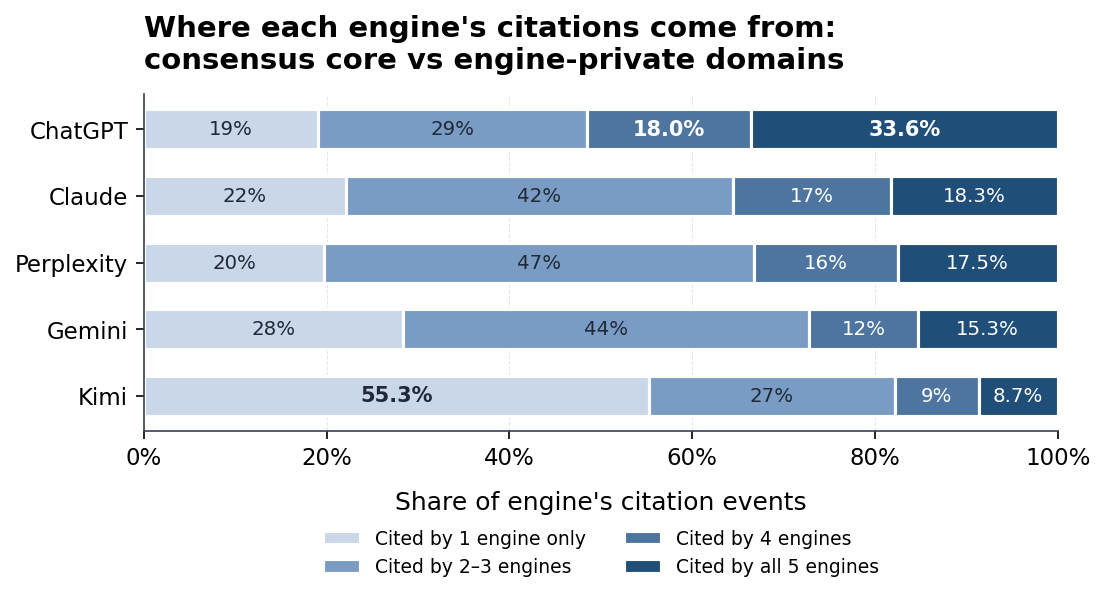


Full four-tier matrix (share of each engine's citations by cited-domain breadth tier):
            Cited by 1 engine only  Cited by 2–3 engines  Cited by 4 engines  Cited by all 5 engines
chatgpt                      0.190                 0.294               0.180                   0.336
claude                       0.221                 0.423               0.173                   0.183
gemini                       0.283                 0.445               0.119                   0.153
kimi                         0.553                 0.269               0.092                   0.087
perplexity                   0.197                 0.470               0.157                   0.175


In [6]:
# Verified from silver citations_scaleup.parquet, registrable-domain normalisation (tldextract,
# TLDExtract(suffix_list_urls=None) applied to the existing 'domain' column, matching
# scripts/build_domain_taxonomy.py's get_pay_level_domain()). Checkpoints reproduced exactly:
# 8,581 total domains; 47 five-engine domains = 14.7% of all citations; 243 four-or-five-engine
# domains = 27.7%; 6,773 single-engine domains = 33.6%; ChatGPT 4-5-engine reliance = 51.5%;
# Kimi single-engine share = 55.3%. If any checkpoint fails below, this cell raises instead of plotting.
import pandas as pd
import tldextract as _tldextract
_EXTRACT = _tldextract.TLDExtract(suffix_list_urls=None)
def _pay_level_domain(d):
    ext = _EXTRACT(str(d))
    return f"{ext.domain}.{ext.suffix}".lower() if (ext.domain and ext.suffix) else str(d).lower().strip()

_cit = pd.read_parquet("data/scaleup/silver/citations_scaleup.parquet").dropna(subset=["domain"]).copy()
_cit["reg_domain"] = _cit["domain"].apply(_pay_level_domain)
_breadth = _cit.groupby("reg_domain")["engine"].nunique()
_cit["breadth"] = _cit["reg_domain"].map(_breadth)
_cit["tier"] = np.select(
    [_cit.breadth == 1, _cit.breadth <= 3, _cit.breadth == 4, _cit.breadth == 5],
    ["t1", "t23", "t4", "t5"], default="t23")  # default unreachable: conditions span breadth 1-5 exhaustively

_n_domains = _cit["reg_domain"].nunique()
_n_cit = len(_cit)
_five = _breadth[_breadth == 5].index
_four_or_five = _breadth[_breadth >= 4].index
_single = _breadth[_breadth == 1].index
_share = lambda doms: _cit["reg_domain"].isin(doms).sum() / _n_cit
_chatgpt = _cit[_cit.engine == "chatgpt"]
_kimi = _cit[_cit.engine == "kimi"]
_checks = [
    ("total domains", _n_domains, 8581),
    ("five-engine domains", len(_five), 47),
    ("five-engine share pct", round(_share(_five) * 100, 1), 14.7),
    ("four-or-five domains", len(_four_or_five), 243),
    ("four-or-five share pct", round(_share(_four_or_five) * 100, 1), 27.7),
    ("single-engine domains", len(_single), 6773),
    ("single-engine share pct", round(_share(_single) * 100, 1), 33.6),
    ("chatgpt 4-5-engine share pct", round(_chatgpt["reg_domain"].isin(_four_or_five).sum() / len(_chatgpt) * 100, 1), 51.5),
    ("kimi single-engine share pct", round(_kimi["reg_domain"].isin(_single).sum() / len(_kimi) * 100, 1), 55.3),
]
_failed = [(name, got, exp) for name, got, exp in _checks if got != exp]
if _failed:
    raise AssertionError(f"Breadth-tier checkpoint mismatch, stopping before plotting: {_failed}")
print("[ok] breadth-tier checkpoints all reproduce:", ", ".join(f"{n}={g}" for n, g, _ in _checks))

tiers = ["Cited by 1 engine only", "Cited by 2–3 engines", "Cited by 4 engines", "Cited by all 5 engines"]
TIER_COLOURS = ["#C9D7E8", "#7A9CC4", "#4D759F", "#1F4E79"]   # sequential, light -> dark; extended one step
_mat = _cit.groupby(["engine", "tier"]).size().unstack(fill_value=0).reindex(columns=["t1","t23","t4","t5"], fill_value=0)
_shares = _mat.div(_mat.sum(axis=1), axis=0)
tier_share = {e: _shares.loc[e].tolist() for e in ENGINE_ORDER}   # per engine, share of its citations by tier

order = sorted(ENGINE_ORDER, key=lambda e: tier_share[e][3])  # by five-engine-tier reliance
fig, ax = plt.subplots(figsize=(7.5, 4.4))
y = np.arange(len(order))
left = np.zeros(len(order))
for t, colour in zip(range(4), TIER_COLOURS):
    vals = np.array([tier_share[e][t] for e in order])
    ax.barh(y, vals, left=left, height=0.6, color=colour,
            edgecolor="white", linewidth=1.5, label=tiers[t])
    for yi, v in enumerate(vals):
        e = order[yi]
        is_five_tier = (t == 3)
        is_named_extreme = (e == "chatgpt" and t in (2, 3)) or (e == "kimi" and t == 0)
        show_1dp = is_five_tier or is_named_extreme
        if v > 0.05:
            ax.text(left[yi] + v / 2, yi, f"{v:.1%}" if show_1dp else f"{v:.0%}",
                    ha="center", va="center",
                    fontsize=10 if is_named_extreme else 9.5,
                    fontweight="bold" if is_named_extreme else "normal",
                    color="white" if t >= 2 else "#1F2937")
    left += vals
ax.set_yticks(y, [ENGINE_LABELS[e] for e in order])
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel("Share of engine's citation events")
ax.set_title("Where each engine's citations come from:\nconsensus core vs engine-private domains", loc="left", pad=12)
ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
ax.yaxis.grid(False)
apply_style(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), ncols=2, fontsize=9)
fig.tight_layout()
savefig(fig, "fig_insights_i12_breadth_tier_shares")
plt.show()

print("\nFull four-tier matrix (share of each engine's citations by cited-domain breadth tier):")
print(pd.DataFrame(tier_share, index=tiers).T.reindex(ENGINE_ORDER).round(3).to_string())


---
## Insight 13 — The citation unit is the deep reference page, not the homepage — but "reference" is earned site identity, not a prose style you can copy

### Engine mechanics
Generative engines cite *pages that answer*, not *sites that brand*. Two source-level facts pin this down:

- **Homepages are almost never the cited object: 98.2% of the 58,851 citation events point to deep pages** (a specific article, entry or document; median path depth 2). Gemini cited a bare homepage in **0.0%** of cases, Claude 1.4%, Kimi 2.2%, Perplexity 2.9%; only ChatGPT reaches even 6.1%. Domain authority gets a page retrieved (Insight 5), but the *citable asset* is always a deep page.
- **Reference-format sources are represented far more faithfully than commercial/editorial prose, on every engine.** Pooling the encyclopedic types (Wikipedia, reference, healthcare-reference), **49–66% of their citation pairs are clearly supported (NLI ≥ 0.50), versus 26–38% for commercial/editorial types** (blogs, news, SaaS/fintech/e-commerce marketing pages) on the same engine. By individual type: Wikipedia 62%, healthcare 51%, reference 45% — against blog 31%, news 25%. These formats are also cited at equal-or-earlier median positions on all five engines (e.g. Kimi position 4 vs 6).
- Two caveats keep this honest. First, the middle of the faithfulness table is **not** "corporate prose": government (24%) and university (24%) pages — institutionally authoritative but often long, dense documents — verify *worse* than blogs (31%), so plain-stated facts beat institutional pedigree at the verification step. Second, these are **associations attached to source identity**: writing "definition-first" prose does not make a site Wikipedia, and Insight 5 shows position is essentially not writable. What *is* transferable is the format's mechanism — self-contained, declarative, verbatim-checkable statements of fact — which is exactly the writable lever set of Insight 4.

### Managerial adaptation
- **Build one deep, reference-style page per money topic** — definition first, facts stated in plain declarative sentences, one topic per page (Insight 7's mid-length architecture) — and treat it, not the homepage or a product page, as the GEO asset you optimise and monitor.
- **Do not expect the reference format alone to win placement.** It reliably improves how faithfully you are quoted (the 49–66% vs 26–38% gap holds on every engine); showing up at all is still governed by the retrieval gate (Insight 2), site-level authority (Insight 5) and lexical query match (Insight 6). It is a strong two-sided lever, not the only one.
- **If your authority pages read like government/university documents, refactor them**: long institutional PDFs and dense multi-section pages sit at the bottom of the verification table despite maximal trust — extract the citable facts into plainly-worded reference entries.

### Visuals — generated chart: the reference-format faithfulness premium


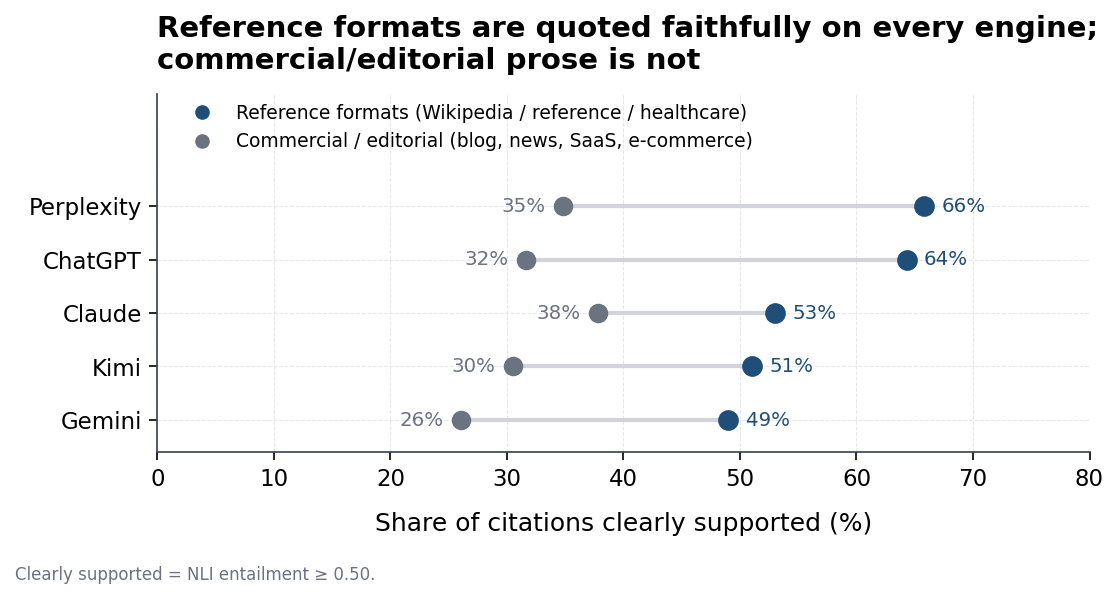

In [7]:
# Verified from flat_table4 entailment pairs joined to citations_scaleup_enriched
# domain_type. Share of (sentence, citation) NLI pairs clearly supported (>= 0.50):
# reference formats = wikipedia + reference + healthcare types; commercial/editorial =
# blog, blogging, news_media, saas, fintech, ecommerce. Homepage share of citations:
# 1.8% overall (ChatGPT 6.1%, Perplexity 2.9%, Kimi 2.2%, Claude 1.4%, Gemini 0.0%).
supp_ref = {"chatgpt": 64.3, "claude": 53.0, "gemini": 49.0,
            "kimi": 51.0, "perplexity": 65.8}
supp_com = {"chatgpt": 31.6, "claude": 37.8, "gemini": 26.1,
            "kimi": 30.5, "perplexity": 34.8}

# Two-colour non-engine scheme (no engine-palette hues; no purple):
REF_COLOUR, COM_COLOUR = COLOUR_PRIMARY, COLOUR_NEUTRAL  # #1F4E79 / #6B7280

order = sorted(ENGINE_ORDER, key=lambda e: supp_ref[e])
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.5, 4.0))
for yi, e in zip(y, order):
    ax.plot([supp_com[e], supp_ref[e]], [yi, yi], color="#D1D5DB",
            linewidth=2, zorder=1)
    ax.scatter(supp_com[e], yi, s=70, color=COM_COLOUR, zorder=2, marker="o")
    ax.scatter(supp_ref[e], yi, s=80, color=REF_COLOUR, zorder=3, marker="o")
    ax.text(supp_com[e] - 1.5, yi, f"{supp_com[e]:.0f}%", ha="right",
            va="center", fontsize=9.5, color=COM_COLOUR)
    ax.text(supp_ref[e] + 1.5, yi, f"{supp_ref[e]:.0f}%", ha="left",
            va="center", fontsize=9.5, color=REF_COLOUR)
ax.set_yticks(y, [ENGINE_LABELS[e] for e in order])
ax.set_ylim(-0.6, len(order) + 1.1)
ax.set_xlim(0, 80)
ax.set_xlabel("Share of citations clearly supported (%)")
ax.set_title("Reference formats are quoted faithfully on every engine;\ncommercial/editorial prose is not", loc="left", pad=12)
ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
ax.yaxis.grid(False)
apply_style(ax)
handles = [plt.Line2D([], [], marker="o", linestyle="", color=REF_COLOUR,
                      label="Reference formats (Wikipedia / reference / healthcare)"),
           plt.Line2D([], [], marker="o", linestyle="", color=COM_COLOUR,
                      label="Commercial / editorial (blog, news, SaaS, e-commerce)")]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.01, 1.02), fontsize=9)
fig.text(0.01, 0.01, "Clearly supported = NLI entailment ≥ 0.50.",
         ha="left", va="bottom", fontsize=8, color="#6B7280")
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


---
## Synthesis — from thirteen insights to an operating model

| # | Adaptation | Replaces (traditional SEO habit) | Primary evidence |
|---|---|---|---|
| 1 | Portfolio allocation by realised citation opportunity | Optimising for the dominant engine's market share | RQ1 Q1–Q2 |
| 2 | Freshness signals to open the retrieval gate | Treating recency as one ranking factor among many | EDA E6/RC1; PF (Kimi) |
| 3 | Per-engine scorecards; no single leaderboard | One rank-tracking dashboard | RQ2 Q9; Domain D6 |
| 4 | One "citable writing" standard (lead query coverage, question titles) | Keyword density and entity stuffing | PF2/PF4 |
| 5 | Site-level authority building over position hacks | On-page tweaks for position | PF1; Domain D3 |
| 6 | Optimise re-citation stickiness via query–title–lead alignment | Celebrating one-off citation screenshots | PF3 |
| 7 | Mid-length single-topic architecture | Skyscraper/ultimate-guide pages | PF5 |
| 8 | Vertical selection and engine × topic matching | Uniform content calendar across verticals | Domain D1/D2/D12 |
| 9 | Verifiability-first formats; misattribution monitoring | Chasing citations in any format | Domain D9–D13; RQ3 Q13 |
| 10 | Measurement governance: k ≥ 8, CV and τ disclosure | Single-run rank checks | RQ2 Q6/Q10/Q11 |
| 11 | Entry strategy per citation economy; platforms as a GEO surface | Assuming one power-law market everywhere | Source-level concentration audit (Insight 11) |
| 12 | Consensus-core vs engine-private-tail route decision | Treating any citation as portable authority | Domain engine-breadth audit (Insight 12) |
| 13 | Deep reference pages as the GEO asset unit | Optimising homepages and brand pages | URL-depth audit + Domain D9 (Insight 13) |

**The through-line:** traditional SEO optimised *where a page appears in a deterministic list*. GEO optimises three stochastic, engine-specific probabilities — **P(retrieval), P(prominent citation | retrieval), P(faithful use | citation)** — and the levers differ at each stage: freshness and query class open retrieval; site-level authority earns position; on-page writing quality (the one transferable playbook) earns faithful and repeated citation; and disciplined measurement makes any of it decision-grade.

*Effect sizes are associations among cited pages in a 250-query audit (single time window, five engines, one NLI verifier); they inform strategy but do not establish causal guarantees.*
